# Day 3 · Notebook 1 — Model showdown
### ML Bootcamp · Day 3 of 5

**Question:** from 30 measurements of a tumour's cells, can we tell if it is **malignant** (cancerous) or **benign**?

In this notebook you will:
1. Meet the breast cancer dataset *(Part 1)*
2. See overfitting happen, see how **one test split can be lucky**, and fix it with **cross-validation** *(Part 2)*
3. Compare 6 models fairly: random forest, gradient boosting, SVM and more *(Part 3)*
4. **Tune** an SVM with GridSearchCV *(Part 4)*
5. Redo the Titanic properly with a **Pipeline** *(Part 5)*

> 🕐 In class: Parts 1–2 in the first hands-on block, Parts 3–5 in the second.
> Run cells in order with **Shift + Enter**. 🧠 = think about it, ✍️ = exercise (solutions at the end).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
print("Ready!")

Ready!


---
## Part 1 · Meet the data
The Wisconsin breast cancer dataset is built into scikit-learn: **569 tumours**, each described by **30 measurements** of cell nuclei seen under a microscope (radius, texture, perimeter, area, smoothness…).

In [2]:
bc = load_breast_cancer()
X, y = bc.data, bc.target

df = pd.DataFrame(X, columns=bc.feature_names)
df["diagnosis"] = pd.Series(y).map({0: "malignant", 1: "benign"})

print("Shape:", X.shape)
print(df["diagnosis"].value_counts())
df.head()

Shape: (569, 30)
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


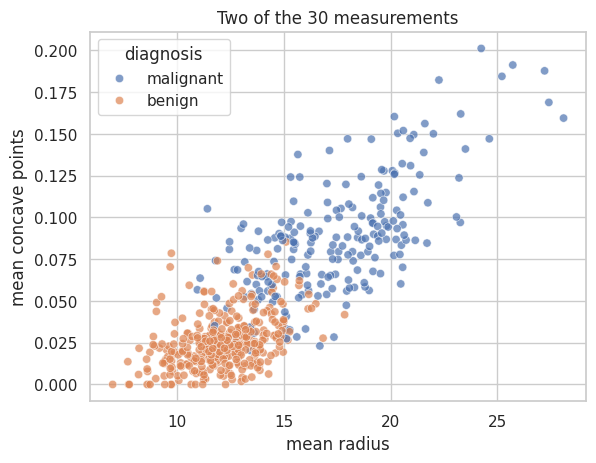

In [3]:
sns.scatterplot(data=df, x="mean radius", y="mean concave points", hue="diagnosis", alpha=0.7)
plt.title("Two of the 30 measurements")
plt.show()

🧠 Even with just two measurements, the two groups are mostly separate. That's a hint that a **simple** model might do well here.

We keep 20% of the tumours aside as a **final test set** and don't touch them until the very end.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, "| Final test:", X_test.shape)

Train: (455, 30) | Final test: (114, 30)


---
## Part 2 · Overfitting and fair testing

### 2.1 Watch overfitting happen
We train decision trees that are allowed to grow deeper and deeper, and compare accuracy on the **training** data with accuracy on the **test** data.

In [5]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
rows = []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    rows.append({"max_depth": "None" if d is None else d,
                 "train": tree.score(X_train, y_train),
                 "test": tree.score(X_test, y_test)})
curve = pd.DataFrame(rows)
curve.round(3)

,max_depth,train,test
0,1,0.923,0.921
1,2,0.958,0.895
2,3,0.976,0.939
3,4,0.987,0.939
4,5,0.993,0.921
5,6,0.998,0.912
6,8,1.000,0.912
7,10,1.000,0.912
8,None,1.000,0.912


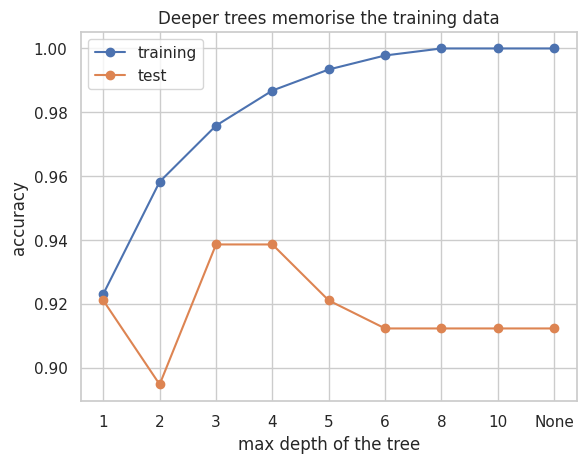

In [6]:
plt.plot(curve["max_depth"].astype(str), curve["train"], marker="o", label="training")
plt.plot(curve["max_depth"].astype(str), curve["test"], marker="o", label="test")
plt.xlabel("max depth of the tree")
plt.ylabel("accuracy")
plt.title("Deeper trees memorise the training data")
plt.legend()
plt.show()

🧠 Training accuracy climbs to 100%, but test accuracy peaks around depth 3–4 and then falls. The growing gap is **overfitting**.

### 2.2 One test split can be lucky
Same model, same data — we only change **which** tumours land in the test set (`random_state` 0 to 9).

In [7]:
scores = []
for seed in range(10):
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    tree = DecisionTreeClassifier(random_state=42).fit(Xa, ya)
    scores.append(tree.score(Xb, yb))
    print(f"split {seed}: {scores[-1]:.1%}")

print(f"\nLowest {min(scores):.1%}, highest {max(scores):.1%}")

split 0: 92.1%
split 1: 95.6%
split 2: 95.6%
split 3: 93.9%
split 4: 87.7%
split 5: 93.0%
split 6: 96.5%
split 7: 93.0%
split 8: 87.7%
split 9: 93.9%

Lowest 87.7%, highest 96.5%


🧠 The score jumps by almost 9 points just from luck! If we compared two models using one split each, we could easily pick the wrong one.

### 2.3 Cross-validation: five exams instead of one
Split the training data into 5 **folds**. Train on 4, test on the 5th, and repeat so every fold is tested once. Report the **average** and the **spread**.

Logistic regression needs scaling, so we put the scaler and the model together in a **pipeline** (more on pipelines in Part 5).

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
fold_scores = cross_val_score(logreg, X_train, y_train, cv=cv)

print("Each fold:", np.round(fold_scores, 3))
print(f"Average: {fold_scores.mean():.1%} ± {fold_scores.std():.1%}")

Each fold: [0.967 0.989 0.978 0.989 0.967]
Average: 97.8% ± 1.0%


> ✋ **End of the first hands-on block.** Go back to the slides — we'll continue with Part 3 soon.

---
## Part 3 · The model showdown
Six models, all tested the same fair way: 5-fold cross-validation on the training set. Models that measure distances (logistic regression, KNN, SVM) get a scaler in a pipeline; tree models don't need one.

In [9]:
models = {
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "KNN (k=5)":           make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Decision tree":       DecisionTreeClassifier(random_state=42),
    "Random forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient boosting":   GradientBoostingClassifier(random_state=42),
    "SVM (RBF)":           make_pipeline(StandardScaler(), SVC()),
}

results, all_folds = [], {}
for name, model in models.items():
    s = cross_val_score(model, X_train, y_train, cv=cv)
    all_folds[name] = s
    model.fit(X_train, y_train)
    results.append({"model": name, "CV mean": s.mean(), "CV spread": s.std(),
                    "final test": model.score(X_test, y_test)})
    print(f"{name:20s} CV {s.mean():.1%} ± {s.std():.1%}")

showdown = pd.DataFrame(results).set_index("model").sort_values("CV mean", ascending=False)
showdown.round(3)

Logistic regression  CV 97.8% ± 1.0%
KNN (k=5)            CV 96.3% ± 1.1%
Decision tree        CV 91.6% ± 1.8%
Random forest        CV 96.3% ± 1.8%
Gradient boosting    CV 95.2% ± 1.5%
SVM (RBF)            CV 96.9% ± 1.5%


,CV mean,CV spread,final test
model,,,
Logistic regression,0.978,0.010,0.982
SVM (RBF),0.969,0.015,0.982
Random forest,0.963,0.018,0.956
KNN (k=5),0.963,0.011,0.956
Gradient boosting,0.952,0.015,0.956
Decision tree,0.916,0.018,0.912


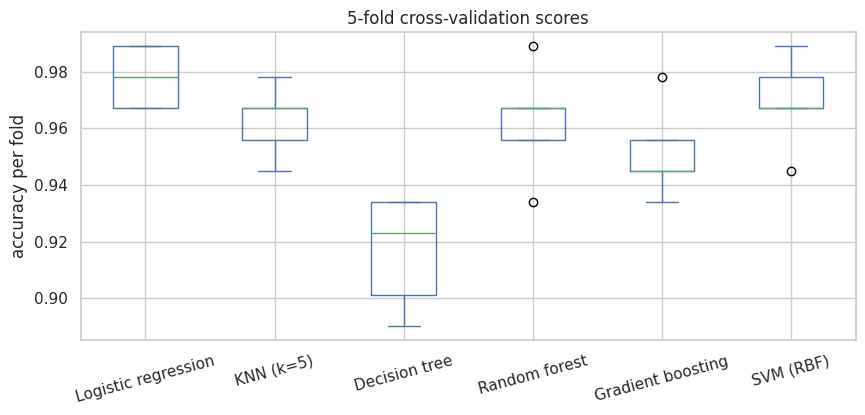

In [10]:
pd.DataFrame(all_folds).plot(kind="box", figsize=(10, 4))
plt.ylabel("accuracy per fold")
plt.title("5-fold cross-validation scores")
plt.xticks(rotation=15)
plt.show()

🧠 The **simplest** model, logistic regression, wins! This data is almost linearly separable, so extra complexity doesn't help. Always try simple first and let cross-validation decide.

### 3.1 What did the random forest rely on?

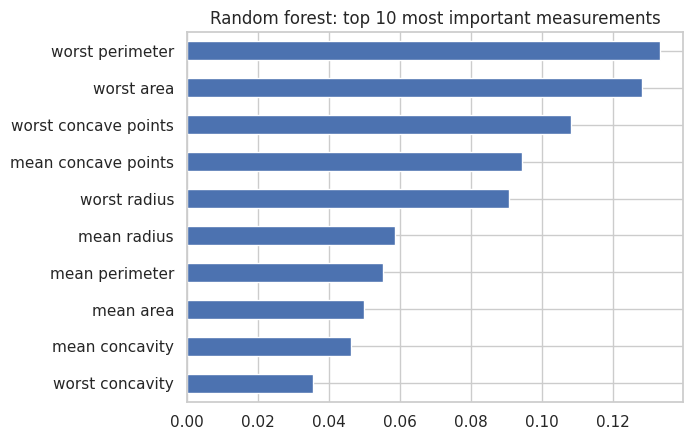

In [11]:
rf = models["Random forest"]
importance = pd.Series(rf.feature_importances_, index=bc.feature_names).sort_values(ascending=False)
importance.head(10).sort_values().plot(kind="barh")
plt.title("Random forest: top 10 most important measurements")
plt.show()

### 3.2 For a medical test, which mistakes matter?
Missing a cancer (a false negative) is much worse than a false alarm. Let's check how many malignant test tumours logistic regression missed.

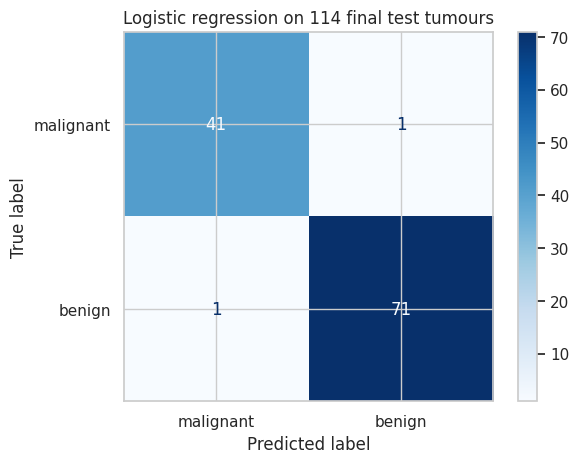

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

best = models["Logistic regression"]
ConfusionMatrixDisplay.from_estimator(best, X_test, y_test,
                                      display_labels=["malignant", "benign"], cmap="Blues")
plt.title("Logistic regression on 114 final test tumours")
plt.show()
print(classification_report(y_test, best.predict(X_test), target_names=["malignant", "benign"]))

---
## Part 4 · Tuning with GridSearchCV
An SVM has two important settings (**hyperparameters**): `C` (how strongly to punish mistakes) and `gamma` (how curvy the boundary may be). GridSearchCV tries every combination with cross-validation. 16 combinations × 5 folds = 80 models.

In [13]:
svm_pipe = Pipeline([("scale", StandardScaler()), ("svm", SVC())])
param_grid = {"svm__C": [0.1, 1, 10, 100],
              "svm__gamma": ["scale", 0.001, 0.01, 0.1]}

grid = GridSearchCV(svm_pipe, param_grid, cv=cv)
grid.fit(X_train, y_train)

print("Best settings:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.1%}")
print(f"Final test accuracy: {grid.score(X_test, y_test):.1%}")

Best settings: {'svm__C': 10, 'svm__gamma': 0.01}
Best CV accuracy: 97.6%
Final test accuracy: 98.2%


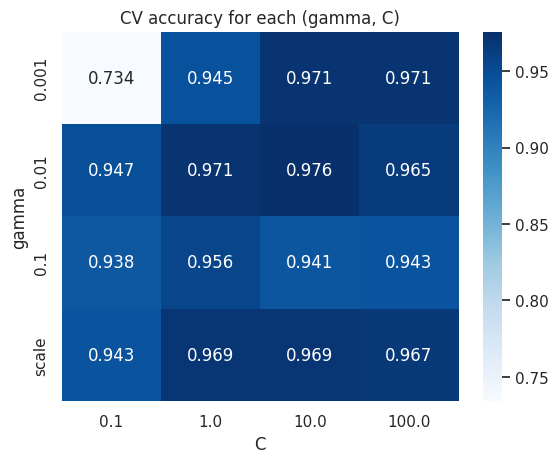

In [14]:
table = pd.DataFrame(grid.cv_results_).pivot(index="param_svm__gamma", columns="param_svm__C", values="mean_test_score")
sns.heatmap(table, annot=True, fmt=".3f", cmap="Blues")
plt.title("CV accuracy for each (gamma, C)")
plt.xlabel("C"); plt.ylabel("gamma")
plt.show()

🧠 Bad settings can be terrible (top-left). The default (`gamma="scale"`, `C=1`) is fine but not the best. We chose the settings using only the training data — the final test set is still untouched.

---
## Part 5 · Titanic, done properly, with a Pipeline
On Day 2 we filled missing ages using the median of the **whole** dataset before splitting — a small leak. A **Pipeline** bundles cleaning + encoding + scaling + model, so every step is learned **inside each training fold only**. It also works directly on raw data.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

titanic = sns.load_dataset("titanic")
titanic["family_size"] = titanic["sibsp"] + titanic["parch"] + 1

num_cols = ["pclass", "age", "sibsp", "parch", "fare", "family_size"]
cat_cols = ["sex", "embarked"]
Xt = titanic[num_cols + cat_cols]      # raw data: missing values and text included!
yt = titanic["survived"]

num_steps = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
cat_steps = make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore"))
prep = ColumnTransformer([("num", num_steps, num_cols), ("cat", cat_steps, cat_cols)])

titanic_models = {
    "Logistic regression": LogisticRegression(max_iter=1000),
    "SVM (RBF)": SVC(),
    "Random forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    "Gradient boosting": GradientBoostingClassifier(random_state=42),
}
cv_t = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, m in titanic_models.items():
    pipe = make_pipeline(prep, m)
    s = cross_val_score(pipe, Xt, yt, cv=cv_t)
    print(f"{name:20s} {s.mean():.1%} ± {s.std():.1%}")

Logistic regression  79.4% ± 1.7%
SVM (RBF)            82.6% ± 1.8%
Random forest        82.7% ± 1.8%
Gradient boosting    83.2% ± 1.6%


🧠 This time the non-linear models (boosting, forest, SVM) beat logistic regression. Titanic has **interactions** — e.g. being female helped much more in 1st class — that a straight line can't capture.

### 5.1 The pipeline predicts straight from raw data
No manual encoding or filling needed — the pipeline remembers every step.

In [16]:
final = make_pipeline(prep, GradientBoostingClassifier(random_state=42)).fit(Xt, yt)

new_passengers = pd.DataFrame([
    {"pclass": 1, "age": 17,     "sibsp": 1, "parch": 1, "fare": 100.0, "family_size": 3, "sex": "female", "embarked": "S"},
    {"pclass": 3, "age": np.nan, "sibsp": 0, "parch": 0, "fare": 7.9,   "family_size": 1, "sex": "male",   "embarked": "S"},
], index=["1st-class girl, 17", "3rd-class man, age unknown"])

for name, p in zip(new_passengers.index, final.predict_proba(new_passengers)[:, 1]):
    print(f"{name}: {p:.0%} chance of survival")

1st-class girl, 17: 96% chance of survival
3rd-class man, age unknown: 8% chance of survival


> ✍️ **Exercises**
> 1. Use `GridSearchCV` to tune a random forest on the breast cancer data: try `n_estimators` in [100, 300] and `max_depth` in [None, 5, 10]. Does it beat logistic regression?
> 2. Use cross-validation to find the best `n_neighbors` for KNN (try 1, 3, 5, 9, 15, 25).
> 3. *(Optional)* Try **XGBoost** on the breast cancer data: `from xgboost import XGBClassifier` (already installed on Colab).

---
## 🎯 Recap
- Compare **train vs test** to spot overfitting
- One split can be lucky → use **cross-validation** (mean ± spread)
- Try **simple first**; ensembles and SVMs are powerful but not always better
- **GridSearchCV** tunes hyperparameters using only training data
- **Pipelines** prevent leakage and work directly on raw data

---
## ✅ Solutions

In [ ]:
# Exercise 1
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       {"n_estimators": [100, 300], "max_depth": [None, 5, 10]}, cv=cv)
rf_grid.fit(X_train, y_train)
print("Best:", rf_grid.best_params_, f"CV {rf_grid.best_score_:.1%}")
print(f"Logistic regression CV was {showdown.loc['Logistic regression', 'CV mean']:.1%} - still the winner.")

In [ ]:
# Exercise 2
for k in [1, 3, 5, 9, 15, 25]:
    s = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)), X_train, y_train, cv=cv)
    print(f"k={k:2d}: {s.mean():.1%} ± {s.std():.1%}")

In [ ]:
# Exercise 3 (optional)
try:
    from xgboost import XGBClassifier
    s = cross_val_score(XGBClassifier(n_estimators=200, eval_metric="logloss"), X_train, y_train, cv=cv)
    print(f"XGBoost CV: {s.mean():.1%} ± {s.std():.1%}")
except ImportError:
    print("XGBoost not installed - run:  !pip install xgboost")